In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importing Dataset

df = pd.read_csv("Occupancy_Estimation.csv")

In [3]:
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017-12-22,10:49:41,24.94,24.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769231,0,0,1
1,2017-12-22,10:50:12,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646154,0,0,1
2,2017-12-22,10:50:42,25.00,24.75,24.50,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519231,0,0,1
3,2017-12-22,10:51:13,25.00,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.10,0.10,0.09,390.0,0.388462,0,0,1
4,2017-12-22,10:51:44,25.00,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846,0,0,1


In [4]:
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10123.000000,10102.000000,10088.000000,10089.000000,10097.000000,10102.000000,10088.000000,10106.000000,10077.000000,10090.000000,10105.000000,10108.000000,10127.000000,10118.000000,10129.000000,10129.000000,10129.000000
mean,25.453952,25.546013,25.054555,25.753068,25.484401,25.855771,34.081582,13.180487,0.168270,0.119833,0.158236,0.103859,460.824035,-0.005420,0.090137,0.079574,0.398559
std,0.351390,0.586600,0.426282,0.356264,51.039823,67.044061,58.308135,19.552846,0.317005,0.266540,0.414080,0.120779,199.953665,1.163510,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.000000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.000000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.000000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.000000,49.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.000000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10123 non-null  float64
 3   S2_Temp               10102 non-null  float64
 4   S3_Temp               10088 non-null  float64
 5   S4_Temp               10089 non-null  float64
 6   S1_Light              10097 non-null  float64
 7   S2_Light              10102 non-null  float64
 8   S3_Light              10088 non-null  float64
 9   S4_Light              10106 non-null  float64
 10  S1_Sound              10077 non-null  float64
 11  S2_Sound              10090 non-null  float64
 12  S3_Sound              10105 non-null  float64
 13  S4_Sound              10108 non-null  float64
 14  S5_CO2                10127 non-null  float64
 15  S5_CO2_Slope       

In [6]:
df.isnull().sum()

Date                     0
Time                     0
S1_Temp                  6
S2_Temp                 27
S3_Temp                 41
S4_Temp                 40
S1_Light                32
S2_Light                27
S3_Light                41
S4_Light                23
S1_Sound                52
S2_Sound                39
S3_Sound                24
S4_Sound                21
S5_CO2                   2
S5_CO2_Slope            11
S6_PIR                   0
S7_PIR                   0
Room_Occupancy_Count     0
dtype: int64

### Handling Missing values

#### Impute with mean values

In [7]:
for i in df[['S1_Temp','S2_Temp','S3_Temp','S4_Temp','S1_Light','S2_Light','S4_Light','S3_Light',
             'S1_Sound','S2_Sound','S3_Sound','S4_Sound','S5_CO2','S5_CO2_Slope']]:
    df[i]=df[i].fillna(df[i].mean())

In [8]:
df.isnull().sum()

Date                    0
Time                    0
S1_Temp                 0
S2_Temp                 0
S3_Temp                 0
S4_Temp                 0
S1_Light                0
S2_Light                0
S3_Light                0
S4_Light                0
S1_Sound                0
S2_Sound                0
S3_Sound                0
S4_Sound                0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
dtype: int64

In [9]:
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017-12-22,10:49:41,24.94,24.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769231,0,0,1
1,2017-12-22,10:50:12,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646154,0,0,1
2,2017-12-22,10:50:42,25.00,24.75,24.50,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519231,0,0,1
3,2017-12-22,10:51:13,25.00,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.10,0.10,0.09,390.0,0.388462,0,0,1
4,2017-12-22,10:51:44,25.00,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846,0,0,1


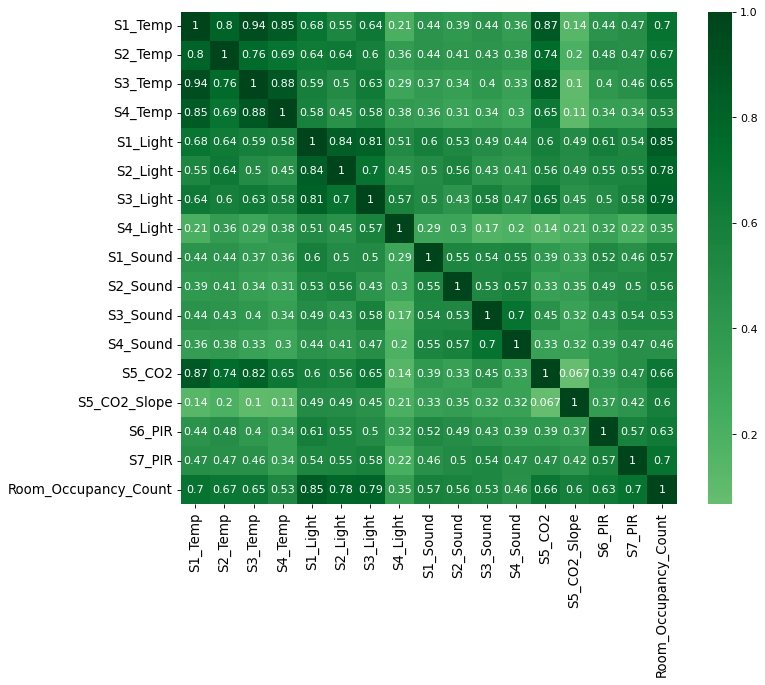

In [10]:
plt.figure(figsize=(10,8), dpi=80)
sns.heatmap(df.corr(), xticklabels = df.corr().columns, yticklabels = df.corr().columns, cmap = 'Greens', center=0, annot=True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Feature Selection and Pruning

In [11]:
df1 = df.drop(labels = ['Date','Time'], axis=1)

In [12]:
df1

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,24.94,24.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769231,0,0,1
1,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646154,0,0,1
2,25.00,24.75,24.50,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519231,0,0,1
3,25.00,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.10,0.10,0.09,390.0,0.388462,0,0,1
4,25.00,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10124,25.06,25.13,24.69,25.31,6.0,7.0,33.0,22.0,0.09,0.04,0.06,0.08,345.0,0.000000,0,0,0
10125,25.06,25.06,24.69,25.25,6.0,7.0,34.0,22.0,0.07,0.05,0.05,0.08,345.0,0.000000,0,0,0
10126,25.13,25.06,24.69,25.25,6.0,7.0,34.0,22.0,0.11,0.05,0.06,0.08,345.0,0.000000,0,0,0
10127,25.13,25.06,24.69,25.25,6.0,7.0,34.0,22.0,0.08,0.08,0.10,0.08,345.0,0.000000,0,0,0


### Spliting Data

In [13]:
X = df1.drop('Room_Occupancy_Count', axis = 1)

In [14]:
X

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR
0,24.94,24.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769231,0,0
1,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646154,0,0
2,25.00,24.75,24.50,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519231,0,0
3,25.00,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.10,0.10,0.09,390.0,0.388462,0,0
4,25.00,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10124,25.06,25.13,24.69,25.31,6.0,7.0,33.0,22.0,0.09,0.04,0.06,0.08,345.0,0.000000,0,0
10125,25.06,25.06,24.69,25.25,6.0,7.0,34.0,22.0,0.07,0.05,0.05,0.08,345.0,0.000000,0,0
10126,25.13,25.06,24.69,25.25,6.0,7.0,34.0,22.0,0.11,0.05,0.06,0.08,345.0,0.000000,0,0
10127,25.13,25.06,24.69,25.25,6.0,7.0,34.0,22.0,0.08,0.08,0.10,0.08,345.0,0.000000,0,0


In [15]:
y = df[['Room_Occupancy_Count']]
y

,Room_Occupancy_Count
0,1
1,1
2,1
3,1
4,1
...,...
10124,0
10125,0
10126,0
10127,0


In [16]:
X.shape

(10129, 16)

In [17]:
y.shape

(10129, 1)

In [18]:
X.shape[0]

10129

In [19]:
y.shape[0]

10129

### Random spliting in train and test data

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2)

### ML Algorithm

In [21]:
clf = svm.SVC()

In [22]:
clf.fit(X_train, y_train)

E:\Anaconda\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [23]:
y_pred = clf.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score", accuracy)

Accuracy Score 0.9726883843369529


In [25]:
cm = confusion_matrix(y_test, y_pred,labels=[0,1])

cm

array([[2449,    1],
       [   0,  147]], dtype=int64)

In [26]:
cr = classification_report(y_test, y_pred)

In [27]:
print("Classification Report: \n", cr)

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2450
           1       0.99      0.99      0.99       148
           2       0.97      0.89      0.93       240
           3       0.85      0.73      0.78       201

    accuracy                           0.97      3039
   macro avg       0.95      0.90      0.92      3039
weighted avg       0.97      0.97      0.97      3039



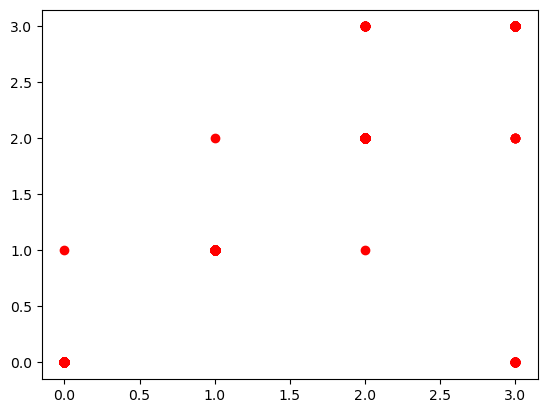

In [28]:
plt.plot(y_test, y_pred,'ro')

In [29]:
y_pred = y_pred.reshape(len(y_test), 1)

In [30]:
y_test.shape

(3039, 1)

In [31]:
import pandas as pd
df = pd.DataFrame(y_pred)
df['index'] = df.index
#df['name'] = df['0']

df.rename(columns={'0': 'Col_1'})

,0,index
0,0,0
1,0,1
2,0,2
3,0,3
4,2,4
...,...,...
3034,0,3034
3035,0,3035
3036,0,3036
3037,0,3037
